In [28]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
#Load Dataset

df = pd.read_csv("nba_players.csv")

df.head()

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [30]:
#Explore Dataset

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   object 
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk   

,0
Unnamed: 0,0
name,0
gp,0
min,0
pts,0
fgm,0
fga,0
fg,0
3p_made,0
3pa,0


In [31]:
#Define the Target Variable

target = "target_5yrs"

X = df.drop(columns=[target])
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1340, 21)
Target: (1340,)


In [32]:
#Drop non-predictive columns

df = df.drop(columns=["Unnamed: 0", "name"])

In [33]:
#Check missing values

df.isnull().sum()

##if any exists

df = df.fillna(df.median(numeric_only=True))

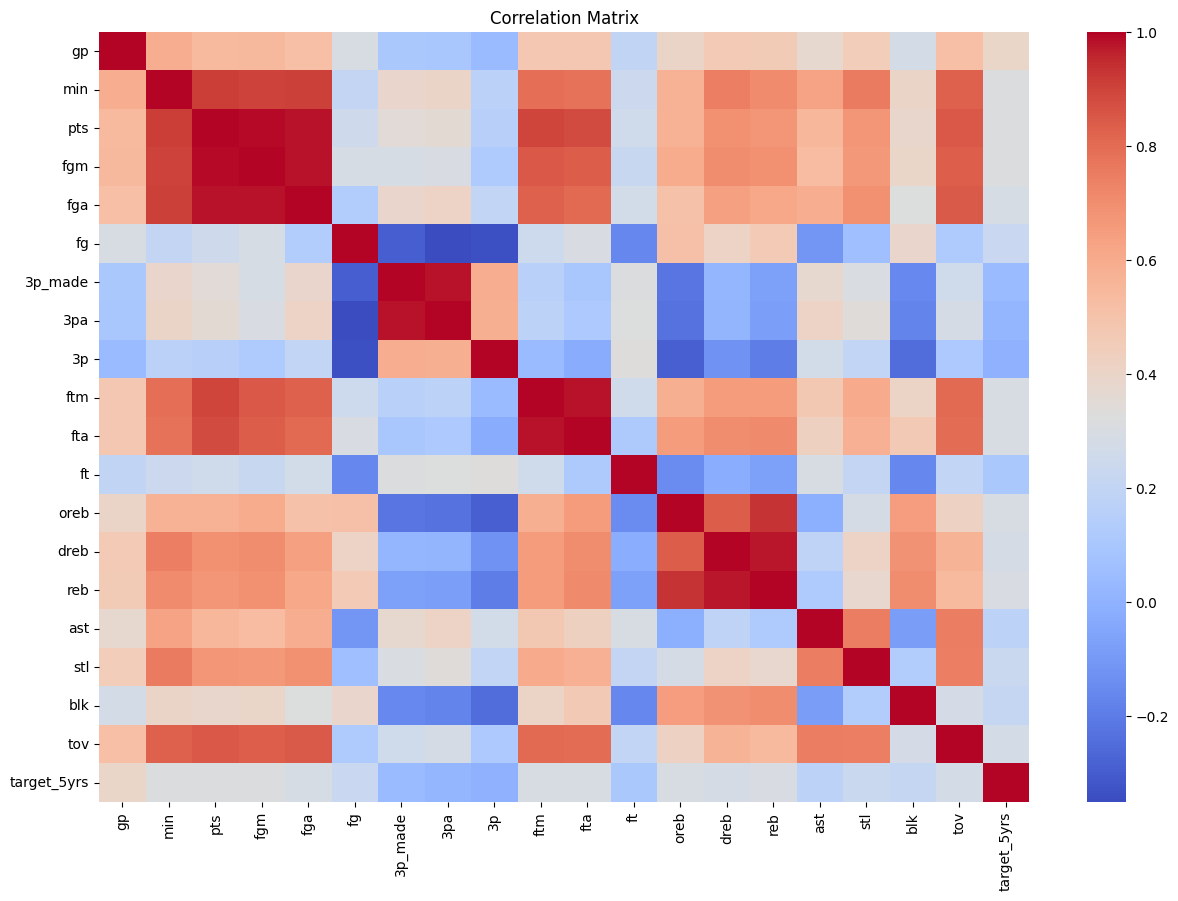

In [34]:
#Correlation Analysis

plt.figure(figsize=(15,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [35]:
#Identify highly correlated features

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print(high_corr)

['pts', 'fgm', 'fga', '3pa', 'fta', 'reb']


In [36]:
#Remove redundant features

df = df.drop(columns=high_corr)

In [37]:
print(df.columns.tolist())

['gp', 'min', 'fg', '3p_made', '3p', 'ftm', 'ft', 'oreb', 'dreb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


In [38]:
df.head()

,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,target_5yrs
0,36,27.4,34.7,0.5,25.0,1.6,69.9,0.7,3.4,1.9,0.4,0.4,1.3,0
1,35,26.9,29.6,0.7,23.5,2.6,76.5,0.5,2.0,3.7,1.1,0.5,1.6,0
2,74,15.3,42.2,0.4,24.4,0.9,67.0,0.5,1.7,1.0,0.5,0.3,1.0,0
3,58,11.6,42.6,0.1,22.6,0.9,68.9,1.0,0.9,0.8,0.6,0.1,1.0,1
4,48,11.5,52.4,0.0,0.0,1.3,67.4,1.0,1.5,0.3,0.3,0.4,0.8,1


In [39]:
df["rebounds_per_min"] = (df["oreb"] + df["dreb"]) / (df["min"] + 1e-5)

df["assists_per_min"] = df["ast"] / (df["min"] + 1e-5)

df["efficiency"] = (
    (df["oreb"] + df["dreb"]) +
    df["ast"] +
    df["stl"] +
    df["blk"] -
    df["tov"]
)

In [40]:
#Check final dataset

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gp                1340 non-null   int64  
 1   min               1340 non-null   float64
 2   fg                1340 non-null   float64
 3   3p_made           1340 non-null   float64
 4   3p                1340 non-null   float64
 5   ftm               1340 non-null   float64
 6   ft                1340 non-null   float64
 7   oreb              1340 non-null   float64
 8   dreb              1340 non-null   float64
 9   ast               1340 non-null   float64
 10  stl               1340 non-null   float64
 11  blk               1340 non-null   float64
 12  tov               1340 non-null   float64
 13  target_5yrs       1340 non-null   int64  
 14  rebounds_per_min  1340 non-null   float64
 15  assists_per_min   1340 non-null   float64
 16  efficiency        1340 non-null   float64


,gp,min,fg,3p_made,3p,ftm,ft,oreb,dreb,ast,stl,blk,tov,target_5yrs,rebounds_per_min,assists_per_min,efficiency
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,60.414179,17.624627,44.169403,0.247612,19.149627,1.297687,70.300299,1.009403,2.025746,1.550522,0.618507,0.368582,1.193582,0.620149,0.171521,0.084030,4.379179
std,17.433992,8.307964,6.137679,0.383688,16.051861,0.987246,10.578479,0.777119,1.360008,1.471169,0.409759,0.429049,0.722541,0.485531,0.073476,0.057725,2.628179
min,11.000000,3.100000,23.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.100000,0.000000,0.026667,0.000000,0.200000
25%,47.000000,10.875000,40.200000,0.000000,0.000000,0.600000,64.700000,0.400000,1.000000,0.600000,0.300000,0.100000,0.700000,0.000000,0.107467,0.041078,2.400000
50%,63.000000,16.100000,44.100000,0.100000,22.200000,1.000000,71.250000,0.800000,1.700000,1.100000,0.500000,0.200000,1.000000,1.000000,0.159430,0.064051,3.800000
75%,77.000000,22.900000,47.900000,0.400000,32.500000,1.600000,77.600000,1.400000,2.600000,2.000000,0.800000,0.500000,1.500000,1.000000,0.229914,0.112926,5.700000
max,82.000000,40.900000,73.700000,2.300000,100.000000,7.700000,100.000000,5.300000,9.600000,10.600000,2.500000,3.900000,4.400000,1.000000,0.435483,0.322580,16.500000


In [41]:
#Save clean dataset

df.to_csv("nba_players_feature_engineered.csv", index=False)